# Space-time annotation of circuits

A PyZX `Circuit` is a flat list of gates: it says *what* happens but not *when*.
The optional `pyzx.spacetime` submodule adds a 1+1D (one space + one time dimension) layer on top of the usual circuit-to-graph conversion:

* give `Circuit.to_graph` a `gate_durations` argument and the gates are scheduled **as soon as possible** in discrete integer time;
* every spider of the resulting ZX-diagram is tagged with a `timestep` (when its gate starts) and a `delay` (how long it takes);
* on top of that you get **space-time cost metrics** of the circuit, a `time_slice` that cuts out the sub-diagram living in a window of timesteps, and a drawing mode that shows the schedule.

Nothing here changes PyZX's behaviour unless you opt in: without `gate_durations` the graph is exactly the one PyZX always produced.

This notebook walks through the scheduler, the annotation, the drawing, the metrics and `time_slice`, and finishes with how the annotation interacts with rewriting.

In [1]:
import sys, os, random
from collections import defaultdict
from fractions import Fraction
sys.path.insert(0, os.path.expanduser('~/git/pyzx')) # git version
sys.path.insert(0, '..')
import pyzx as zx
from pyzx.circuit import Circuit
from pyzx.circuit.gates import CNOT, HAD, T
from pyzx.spacetime import schedule_gates, used_qubits

## 1. The scheduler: `spacetime.schedule_gates`

Scheduling is done by an **as-soon-as-possible (ASAP)** rule:

* every qubit carries an integer clock, starting at `0`;
* a gate starts at the largest clock among the qubits it touches (`used_qubits` says which);
* afterwards those clocks advance by `max(duration, 1)`, so two causally ordered gates always land on distinct timesteps even when every duration is `0`.

Independent gates therefore share a timestep, dependent gates serialise, and the order in which you *wrote* the gates is irrelevant.

Start with a sequential-looking circuit that has a lot of parallelism: a layer of Hadamards, some CNOTs, a layer of `T` gates, and a final long-range CNOT.

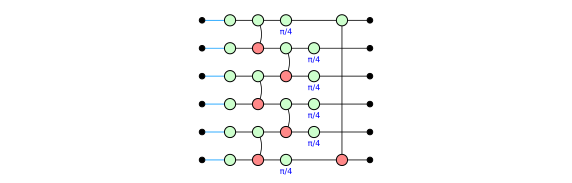

In [2]:
c = Circuit(6)
for q in range(6):
    c.add_gate(HAD(q))                                        # 6 independent gates
c.add_gate(CNOT(0, 1)); c.add_gate(CNOT(2, 3)); c.add_gate(CNOT(4, 5))  # 3 disjoint CNOTs
c.add_gate(CNOT(1, 2)); c.add_gate(CNOT(3, 4))                # bridge the pairs -> must wait
for q in range(6):
    c.add_gate(T(q))                                          # 6 independent gates
c.add_gate(CNOT(0, 5))                                        # long-range, waits for both

zx.draw_matplotlib(c, figsize=(10, 3))

Numbering the gates `0, 1, 2, ...` (one gate per timestep, the naive reading) would make this circuit 18 deep. The ASAP schedule:

In [16]:
sched = schedule_gates(c.gates)          # no durations: pure dependency layering

layers = defaultdict(list)
for g, (t, d) in zip(c.gates, sched):
    layers[t].append(str(g))
for t in sorted(layers):
    print(f"t={t}: " + ", ".join(layers[t]))

print()
print("naive depth (one gate per tick):", len(c.gates))
print("ASAP depth                     :", max(layers) + 1)

t=0: HAD(0), HAD(1), HAD(2), HAD(3), HAD(4), HAD(5)
t=1: CNOT(0,1), CNOT(2,3), CNOT(4,5)
t=2: CNOT(1,2), CNOT(3,4), T(0), T(5)
t=3: T(1), T(2), T(3), T(4), CNOT(0,5)

naive depth (one gate per tick): 18
ASAP depth                     : 4


18 gates collapse to **4 timesteps**:

* `t=0` — all six Hadamards, they touch disjoint qubits;
* `t=1` — the three disjoint CNOTs run together;
* `t=2` — the two bridging CNOTs, *plus* `T(0)` and `T(5)`, which slid forward because qubits 0 and 5 are idle;
* `t=3` — the remaining `T` gates and the long-range `CNOT(0, 5)`.

The schedule follows data dependencies, not list order. Rebuild the same circuit with every independent group shuffled: the gate → timestep assignment is unchanged.

In [4]:
c2 = Circuit(6)
hs = [HAD(q) for q in range(6)]; random.Random(0).shuffle(hs)
for g in hs:
    c2.add_gate(g)
for g in [CNOT(4, 5), CNOT(0, 1), CNOT(2, 3), CNOT(3, 4), CNOT(1, 2)]:
    c2.add_gate(g)
ts = [T(q) for q in range(6)]; random.Random(1).shuffle(ts)
for g in ts:
    c2.add_gate(g)
c2.add_gate(CNOT(0, 5))

def gate_to_timestep(circ):
    return {str(g): t for g, (t, _) in zip(circ.gates, schedule_gates(circ.gates))}

print("same schedule after shuffling:", gate_to_timestep(c) == gate_to_timestep(c2))

same schedule after shuffling: True


And it does not parallelise a genuine dependency chain. In a GHZ ladder each `CNOT` needs the result of the previous one, so depth stays equal to the number of gates.

In [5]:
ghz = Circuit(6)
ghz.add_gate(HAD(0))
for q in range(5):
    ghz.add_gate(CNOT(q, q + 1))

for g, (t, d) in zip(ghz.gates, schedule_gates(ghz.gates)):
    print(f"t={t}: {g}")

t=0: HAD(0)
t=1: CNOT(0,1)
t=2: CNOT(1,2)
t=3: CNOT(2,3)
t=4: CNOT(3,4)
t=5: CNOT(4,5)


## 2. Opting in: `to_graph(gate_durations=...)`

`gate_durations` maps a gate class (`pyzx.circuit.gates.CNOT`) or a gate name (`"CNOT"`) to a non-negative integer duration. A gate that appears in neither is instantaneous (duration `0`). Passing `{}` opts in with every gate instantaneous — a pure dependency layering like the one above.

`spacetime.has_time_data` tells you whether a graph carries the annotation. Without `gate_durations` it does not:

has_time_data: False


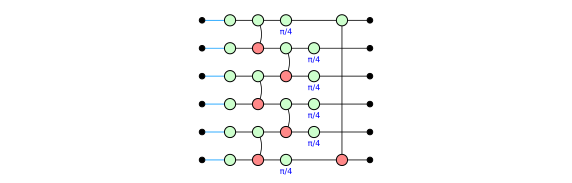

In [6]:
g_plain = c.to_graph()
print("has_time_data:", zx.spacetime.has_time_data(g_plain))
zx.draw_matplotlib(g_plain, figsize=(10, 3))

With durations, every spider created by a gate is tagged with that gate's `(timestep, delay)`. Input boundaries sit at timestep `0` and output boundaries at the tick after the last gate finishes. Here a `CNOT` takes 3 ticks and a `T` gate 1; the Hadamards are instantaneous.

In [7]:
durations = {"CNOT": 3, "T": 1}
g = c.to_graph(gate_durations=durations)
print("has_time_data:", zx.spacetime.has_time_data(g))

has_time_data: True


## 3. Per-spider data

`timestep` and `delay` are ordinary vertex data (`g.vdata(v, 'timestep')`), so any backend supports them and the graph is still a plain `GraphS`. The accessors `spacetime.get_timestep` / `spacetime.get_delay` are the convenient way to read them.

In [8]:
print(f"{'vertex':>6} {'type':<9} {'qubit':>5} {'timestep':>9} {'delay':>6}")
for v in list(g.vertices())[:16]:
    print(f"{v:>6} {zx.VertexType(g.type(v)).name:<9} {g.qubit(v):>5} "
          f"{str(zx.spacetime.get_timestep(g, v)):>9} {zx.spacetime.get_delay(g, v):>6}")

vertex type      qubit  timestep  delay
     0 BOUNDARY      0         0      0
     1 BOUNDARY      1         0      0
     2 BOUNDARY      2         0      0
     3 BOUNDARY      3         0      0
     4 BOUNDARY      4         0      0
     5 BOUNDARY      5         0      0
     6 Z             0         0      0
     7 Z             1         0      0
     8 Z             2         0      0
     9 Z             3         0      0
    10 Z             4         0      0
    11 Z             5         0      0
    12 X             1         1      3
    13 Z             0         1      3
    14 X             3         1      3
    15 Z             2         1      3


## 4. Drawing the schedule

`draw` / `draw_matplotlib` take a `show_time` flag. Each timed spider is labelled `t<timestep>`, and a wire whose earlier spider has `delay > 0` is drawn as a squiggle labelled `Δ<delay>`, with one wiggle per tick. Instantaneous wires look exactly as they always did.

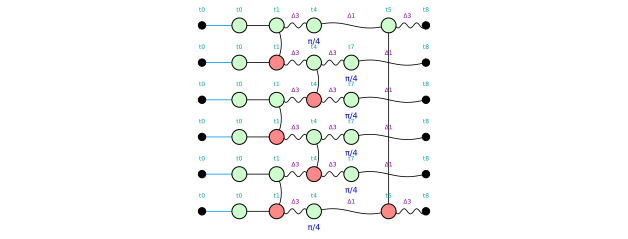

In [9]:
zx.draw_matplotlib(g, show_time=True, figsize=(11, 4))

## 5. Space-time cost metrics

`spacetime.spacetime_metrics` summarises the schedule of a graph:

* `num_timesteps` — number of distinct ticks on which some gate starts (parallel layers);
* `time_depth` — wall-clock span, `last_tick - first_tick + 1`;
* `spacetime_volume` — sum over every occupied tick of the number of qubits busy on that tick;
* `total_delay` — sum of all `delay` values.

`spacetime.time_extent` returns the `(first, last)` tick pair. Compare the all-instantaneous schedule with the one where a `CNOT` takes 3 ticks:

In [10]:
g_fast = c.to_graph(gate_durations={})          # every gate instantaneous
g_slow = g                                       # CNOT takes 3, T takes 1

print("all instantaneous :", zx.spacetime.spacetime_metrics(g_fast), zx.spacetime.time_extent(g_fast))
print("CNOT=3, T=1       :", zx.spacetime.spacetime_metrics(g_slow), zx.spacetime.time_extent(g_slow))

all instantaneous : {'num_timesteps': 4, 'time_depth': 4, 'spacetime_volume': 24, 'total_delay': 0} (0, 3)
CNOT=3, T=1       : {'num_timesteps': 5, 'time_depth': 8, 'spacetime_volume': 48, 'total_delay': 42} (0, 7)


`time_depth` grows because gates on a qubit that is mid-CNOT have to wait, and `spacetime_volume` grows because each CNOT now paints three cells per qubit instead of one. `num_timesteps` barely changes — the gates still start in the same few waves, they just take longer to finish. This is the kind of comparison you make when trading time against qubit count between two implementations of the same operation.

## 6. A window of the computation: `time_slice`

`spacetime.time_slice(g, start, stop)` returns the sub-diagram of spiders whose occupied interval `[timestep, timestep + delay]` meets the inclusive window `[start, stop]` (`stop` defaults to `start`). Every edge crossing the cut is closed off with a fresh boundary vertex — an input if the dropped neighbour lies before the window, an output otherwise — so the result is a valid ZX-diagram, with inputs and outputs in qubit order, that you can simplify or compare on its own.

Take the window covering the first CNOT layer:

kept 18 vertices; inputs (6, 7, 8, 9, 10, 11) outputs (13, 12, 15, 14, 17, 16)


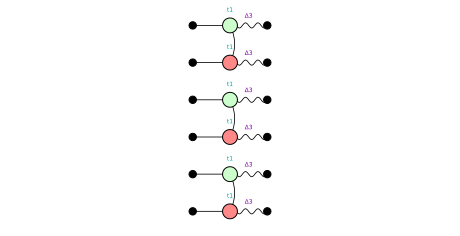

In [11]:
window = zx.spacetime.time_slice(g, 1, 3)
print("kept", window.num_vertices(), "vertices;",
      "inputs", window.inputs(), "outputs", window.outputs())
zx.draw_matplotlib(window, show_time=True, figsize=(8, 4))

A typical use is to check what linear map a sub-circuit implements. Build a phase gadget as a CNOT ladder around a `T` (a `ParityPhase`) with some gates before and after it, work out from the schedule which ticks the gadget occupies, slice that window out, simplify, and compare it against the gadget alone.

Note that `time_slice` returns *everything* scheduled in the window: if some other gate on an idle qubit were scheduled concurrently with the gadget, it would be part of the slice too. Here the trailing `CNOT(0, 2)` has to wait for the whole ladder, so it stays out.

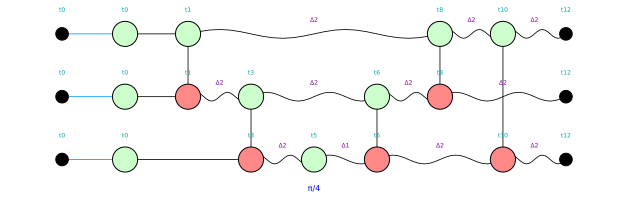

In [12]:
from pyzx.circuit.gates import ParityPhase

longer = Circuit(3)
longer.add_gate(HAD(0)); longer.add_gate(HAD(1)); longer.add_gate(HAD(2))
longer.add_gate(ParityPhase(Fraction(1, 4), 0, 1, 2))     # the gadget: 5 basic gates
longer.add_gate(CNOT(0, 2))

durs = {"CNOT": 2, "ZPhase": 1}
g_long = longer.to_graph(gate_durations=durs)
zx.draw_matplotlib(g_long, show_time=True, figsize=(11, 3))

gadget occupies ticks 1 to 9
slice == ParityPhase(1/4, 0, 1, 2): True


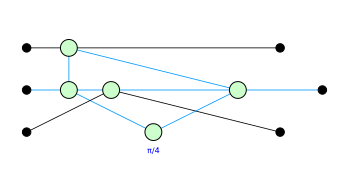

In [13]:
# Which ticks does the gadget occupy?  Ask the scheduler about its five basic gates
# (a gate with delay d occupies ticks [t, t + max(d, 1))).
basic = longer.to_basic_gates()
sched = schedule_gates(basic.gates, durs)
gadget_sched = sched[3:8]                    # after the three Hadamards
start = min(t for t, _ in gadget_sched)
stop = max(t + max(d, 1) - 1 for t, d in gadget_sched)
print("gadget occupies ticks", start, "to", stop)

gadget_window = zx.spacetime.time_slice(g_long, start, stop)
zx.full_reduce(gadget_window)

gadget_only = Circuit(3)
gadget_only.add_gate(ParityPhase(Fraction(1, 4), 0, 1, 2))
print("slice == ParityPhase(1/4, 0, 1, 2):",
      zx.compare_tensors(gadget_window, gadget_only.to_graph(), preserve_scalar=False))
zx.draw_matplotlib(gadget_window, figsize=(6, 3))

## 7. Interaction with the rest of PyZX

A timed graph is an ordinary `GraphS`. Simplification, extraction and tensor evaluation give the same result as on the untimed graph:

In [14]:
timed   = c.to_graph(gate_durations=durations)
untimed = c.to_graph()

a = timed.copy();   zx.clifford_simp(a, quiet=True)
b = untimed.copy(); zx.clifford_simp(b, quiet=True)
print("same vertex count after clifford_simp:", a.num_vertices() == b.num_vertices())
print("same tensor                          :", zx.compare_tensors(a, b, preserve_scalar=False))

c_out = zx.extract_circuit(a.copy())
print("extracted circuit equals the original:", zx.compare_tensors(c_out, c, preserve_scalar=False))

same vertex count after clifford_simp: True
same tensor                          : True
extracted circuit equals the original: True


Rewrite rules do not maintain the annotation: fusing two spiders keeps the survivor's `timestep`, and freshly created spiders have none. Nothing raises — `spacetime_metrics` skips untimed spiders and `time_slice` drops them — but the numbers are only *meaningful* on a graph that still corresponds to a scheduled circuit.

24 / 24 spiders still carry a timestep after clifford_simp


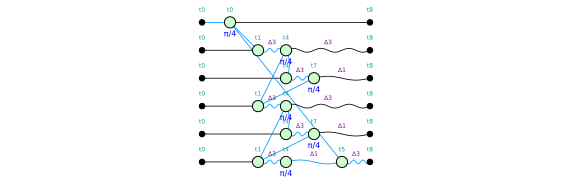

In [15]:
still_timed = sum(1 for v in a.vertices() if zx.spacetime.get_timestep(a, v) is not None)
print(f"{still_timed} / {a.num_vertices()} spiders still carry a timestep after clifford_simp")
zx.draw_matplotlib(a, show_time=True, figsize=(10, 3))

The recommended workflow is therefore: annotate → inspect, slice, draw, measure; and when you want to simplify, work on a `.copy()` and treat the result as untimed. `to_qasm()`, `to_tensor()` and `to_graph()` round-trips are all unaffected by the annotation.